# Notebook 1 - Introduction to Scikit-Learn
---
*Christian Jelo R. Artoza*

Notes I took from the book *Python Data Science Handbook* by Vanderplas. I'm currently reading Chapter 5, which is supposed to be an introduction to machine learning. It introduces some of the basic machine learning models, going in-depth with a couple of classification, regression, clustering, and dimensional reduction models. I've decided to follow this one along with the machine learning course I'm taking; since machine learning is one of, if not, the most important subject.

## Data Representation in Scikit-Learn

### Data as table

In [2]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Each row pertains to an observed flower. Rows are referred to as *samples*, and the total number of samples is referred to as `n_samples`

The columns represents the aspects of the observed flower and are referred to as the *features*. The number of columns are called `n_features`

### Features Matrix

Information that are formatted this way can be thought of as a two-dimensional array/matrix.

We will call such two-dimensional arrays as a *Features matrix* with shape `[n_sample, n_features]`, and we usually stored in the variable `X`.

Feature matrices are often contained in a Pandas `DataFrame` (the case for the above example) or a Numpy array.

### Target Array

In addition to the features matrix `X`, we also usually work with a *target array* which we denote with `y`.

A target array is usually contained in a Pandas `Series` or a Numpy array. elements of the target array can be continuous numerical values or discrete categorical values (labels).

A target array is most often one-dimensional; however, Scikit-Learn does have capabilities to work on two-dimensional target arrays.

**Important**: A target array represents the quantity we want to predict/optimize (the dependent variable). For example, in the laptop sales data set we used in Course 7, we had the target array `price`.

In the `iris` dataset, the `species` column is our target array.

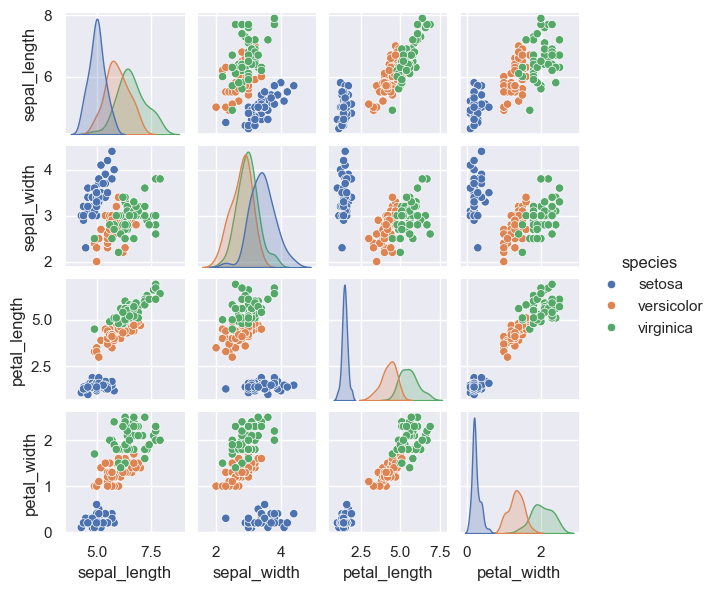

In [3]:
%matplotlib inline
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
sns.pairplot(iris, hue='species', height=1.5)

plt.show()

The above code provides an easy way to see the relationship between each feature (e.g. `sepal_length`, `petal_width`). The colors represent the target array `species`.

To be able to use Scikit-Learn, we need to format the data properly. And the proper format is a features matrix `X` and the target array `y` in the dataframe, both with the same number of samples.

So, it would be good for us to separate a dataframe into `X` and `y` before working with them using Scikit-Learn.

In [4]:
# Features matrix - as Pandas DataFrame
X_iris = iris.drop('species', axis=1)

# Target array - as Pandas Series
y_iris = iris['species']

print('Shapes:')
print('  features matrix:  ', X_iris.shape)
print('  target array:     ', y_iris.shape)

Shapes:
  features matrix:   (150, 4)
  target array:      (150,)


## Scikit-Learn's Estimator API

### Basics of the API
The steps in using the *estimator* API are as follows:
1. Choose a class of model
2. Choose hyperparameters for the model of choice
3. Arrange the data into a features matrix `X` and a target array `y`.
4. Use the method `fit()` to train the model against the data.
5. Use the trained model against new data:
   - For supervised learning, we use `Predict()` to predict labels of newly observed data.
   - For unsupervised learning, we transform or infer properties of newly observed data using `Transform()` or `Predict()`.

### Supervised learning example: Simple linear regression

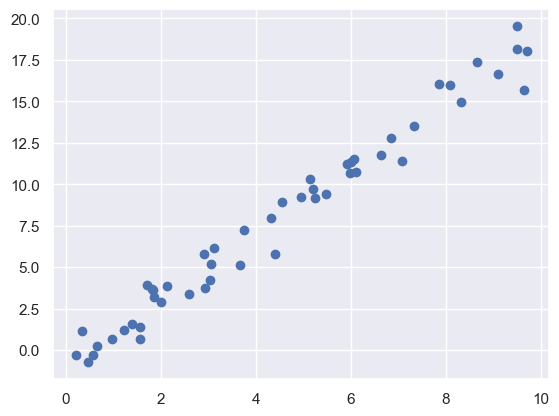

In [5]:
import numpy as np

#Pseudo Random Number Generator
rng = np.random.RandomState(42)

# rng.rand(50) generates an array of 50 samples from a uniform distribution of [0,1]
x = 10 * rng.rand(50) 

# rng.randn(50) generates 50 samples from the normal distribution
y = 2 * x - 1 + rng.randn(50)

plt.scatter(x,y)
plt.show()

#### 1. Choose a class of model
Every model is a class in Scikit-Learn. Once, we have a model in mind, we can import that model as a class.

In [6]:
# In this example we'll be using the LinearRegression model class

from sklearn.linear_model import LinearRegression

#### 2. Choose model hyperparameters
Create an instance of the model and pass the hyperparameters of choice in the instance.

A couple of hyperparameters that we would like to consider are for the following purposes:
1. Fitting for the offset (i.e., intercept)
2. Normalization -- to ensure features are at the same scale
3. Pre-processing of features to add model flexibility
4. Degree of regularization -- constraints/penalties to prevent overfitting and underfitting
5. Specifying how many components to keep (probably gonna learn more about this later...)

In [7]:
# We want to fit for the offset
# So we create an instance of the LinearRegression model class
# and pass the hyperparameter to fit for the offset

model = LinearRegression(fit_intercept=True)
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 3. Arrange data into features matrix `X` and target array `y`

In our case, the target array is `y` and we already defined that in the correct format. But we have to convert `x` into a two-dimensional matrix; it is currently one-dimensional (just a vector).

In [8]:
# We can increase the dimension of x by one unit with np.newaxis

X = x[:, np.newaxis]
print('dimensions of x:                 ', x.shape)
print('dimensions of features matrix X: ', X.shape)

dimensions of x:                  (50,)
dimensions of features matrix X:  (50, 1)


#### 4. Fit the model to the data
For this, we use the `fit()` method. This causes some internal computations to take place; the result of the computations are then stored as attributes of the model.

By convention, the names of the attributes have trailing underscores.

In [9]:
# Fit the model using fit()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Results are stored as attributes of `model`
# The slope of the regression line is saved to the `coef_` attribute
# The intercept is saved to the `intercept_` attribute

print('Regression Line')
print(f' slope:    {model.coef_}')
print(f' intercept {model.intercept_}')

Regression Line
 slope:    [1.9776566]
 intercept -0.903310725531111


#### 5. Predict labels for unknown data
Now for the main task, evaluating the model by testing it against data that were not part of the data used for training.

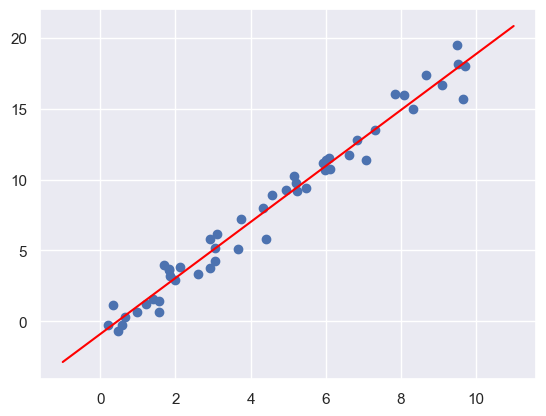

In [11]:
# Our model was fitted to points between 0 and 10.
# We'll evaluate the model by checking its values on points outside that range
# Let's try [-1,0] and [10,11)

xfit = np.linspace(-1,11)  #define the test set
Xfit = xfit[:, np.newaxis] #similar to the x data used for training, we have to make it 2d
yfit = model.predict(Xfit) #predict values for xfit

# Create a plot
plt.scatter(x,y)
plt.plot(xfit,yfit,color='red')
plt.show()

### Supervised learning example: Iris classification

*Question:* Given a model trained on a portion of the Iris dataset, how well can the model predict the labels of the remaining portion?

For this task, we will use the *Gaussian naive Bayes*. It is quick and there are no hyperparameters to specify. It is often a good model to use as a baseline classification.

In [50]:
# 1. Class of model - Gaussian naive Bayes
from sklearn.naive_bayes import GaussianNB

# 2. No hyperparameters neededm, but we still have to create an instance
model = GaussianNB()

# 3. Split up the dataset into a training set and a test set using the train_test_split class
# this was discussed in course 7
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris, random_state=1)

# 4. Fit the model to the training set
model.fit(Xtrain,ytrain)

# 5. Predict labels of the test data
y_model = model.predict(Xtest)

for i in range(0,ytest.shape[0]):
    if ytest.values[i] != y_model[i]:
        print('actual value:    ', str(ytest.values[i]))
        print('predicted value: ', str(y_model[i]))

iris.loc[[84],:]

actual value:     versicolor
predicted value:  virginica


,sepal_length,sepal_width,petal_length,petal_width,species
84,5.4,3.0,4.5,1.5,versicolor


As we can see from the result, it actually did well for a simple classification model; it made correct predictions for most of it except for one.

A better way to evaluate the model is to use the `accuracy_score` function. This outputs the fraction of predicted labels that match the actual.

In [39]:
from sklearn.metrics import accuracy_score
print('accuracy score: ', accuracy_score(ytest, y_model))

accuracy score:  0.9736842105263158


This tells us that 97.4% of the predicted labels match the actual.

### Unsupervised learning example: Iris dimensionality